In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [12]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/workspaces/Heart-Attack-Predictor/data/raw/heart_attack_prediction_dataset.csv')

# Preview data
data.head()


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [13]:
# Basic info
data.info()

# Check for missing values
print(data.isnull().sum())

# Summary statistics
data.describe()

# Check unique values for categorical columns
for col in data.columns:
    if data[col].dtype == 'object' or data[col].nunique() < 10:
        print(f"{col} ➜ {data[col].unique()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

Exploratory Data Analysis (EDA)

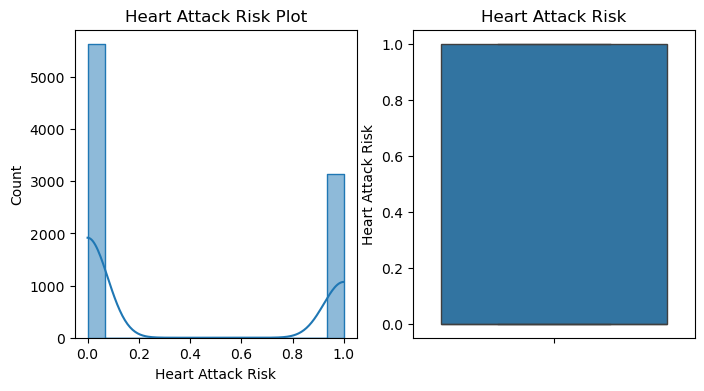

In [14]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title('Heart Attack Risk Plot')
sns.histplot(data["Heart Attack Risk"], kde=True, element='step')

plt.subplot(1,2,2)
sns.boxplot(data["Heart Attack Risk"])
plt.title('Heart Attack Risk')

plt.show()

In [15]:
categorical_features = [x for x in data.columns if data[x].dtype =='object']
categorical_features

['Patient ID',
 'Sex',
 'Blood Pressure',
 'Diet',
 'Country',
 'Continent',
 'Hemisphere']

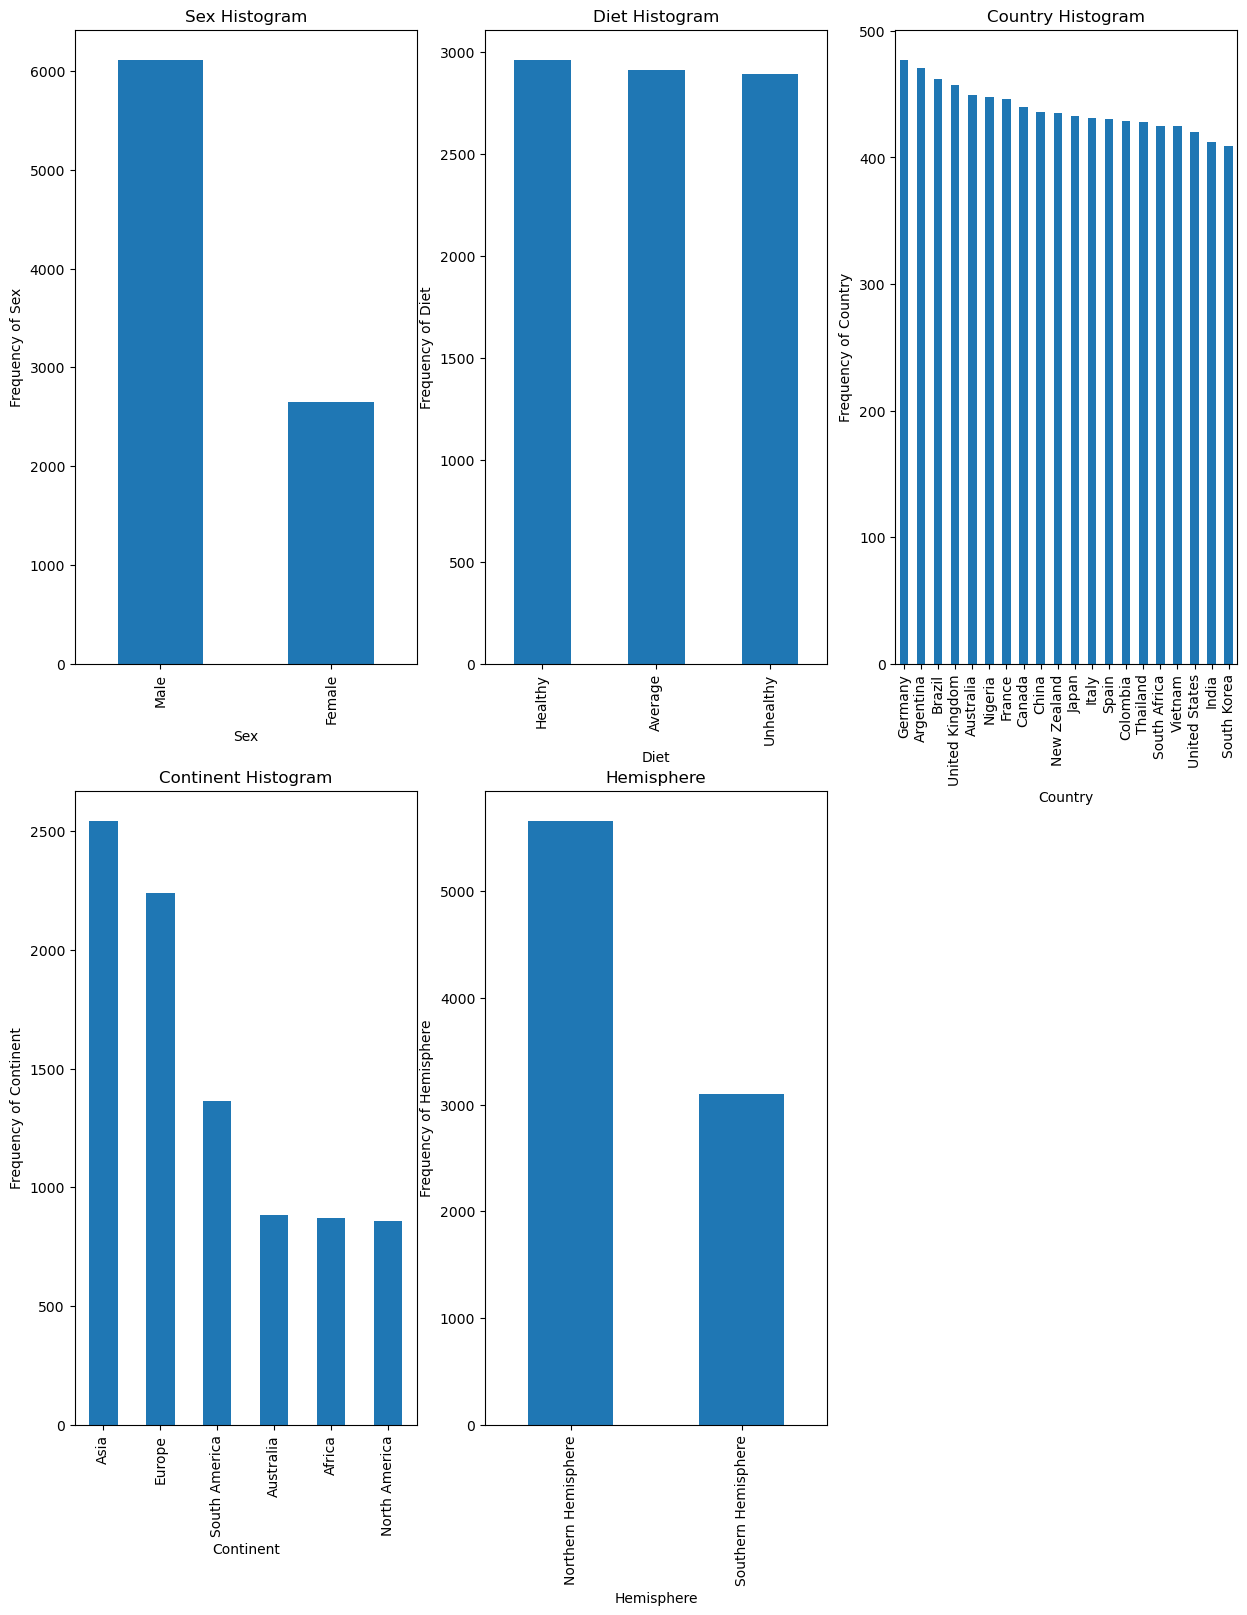

In [16]:
plt.figure(figsize=(15, 28))

plt.subplot(3, 3, 1)
plt1 = data['Sex'].value_counts().plot(kind='bar')
plt.title('Sex Histogram')
plt1.set(xlabel = 'Sex', ylabel='Frequency of Sex')

plt.subplot(3, 3, 2)
plt1 = data['Diet'].value_counts().plot(kind='bar')
plt.title('Diet Histogram')
plt1.set(xlabel = 'Diet', ylabel='Frequency of Diet')

plt.subplot(3, 3, 3)
plt1 = data['Country'].value_counts().plot(kind='bar')
plt.title('Country Histogram')
plt1.set(xlabel = 'Country', ylabel='Frequency of Country')

plt.subplot(3, 3, 4)
plt1 = data['Continent'].value_counts().plot(kind='bar')
plt.title('Continent Histogram')
plt1.set(xlabel = 'Continent', ylabel='Frequency of Continent')

plt.subplot(3, 3, 5)
plt1 = data['Hemisphere'].value_counts().plot(kind='bar')
plt.title('Hemisphere')
plt1.set(xlabel = 'Hemisphere', ylabel='Frequency of Hemisphere')

plt.show()

In [17]:
numerical_features = [x for x in data.columns if data[x].dtype in ('int64','float64')]
print(numerical_features)

['Age', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Heart Attack Risk']


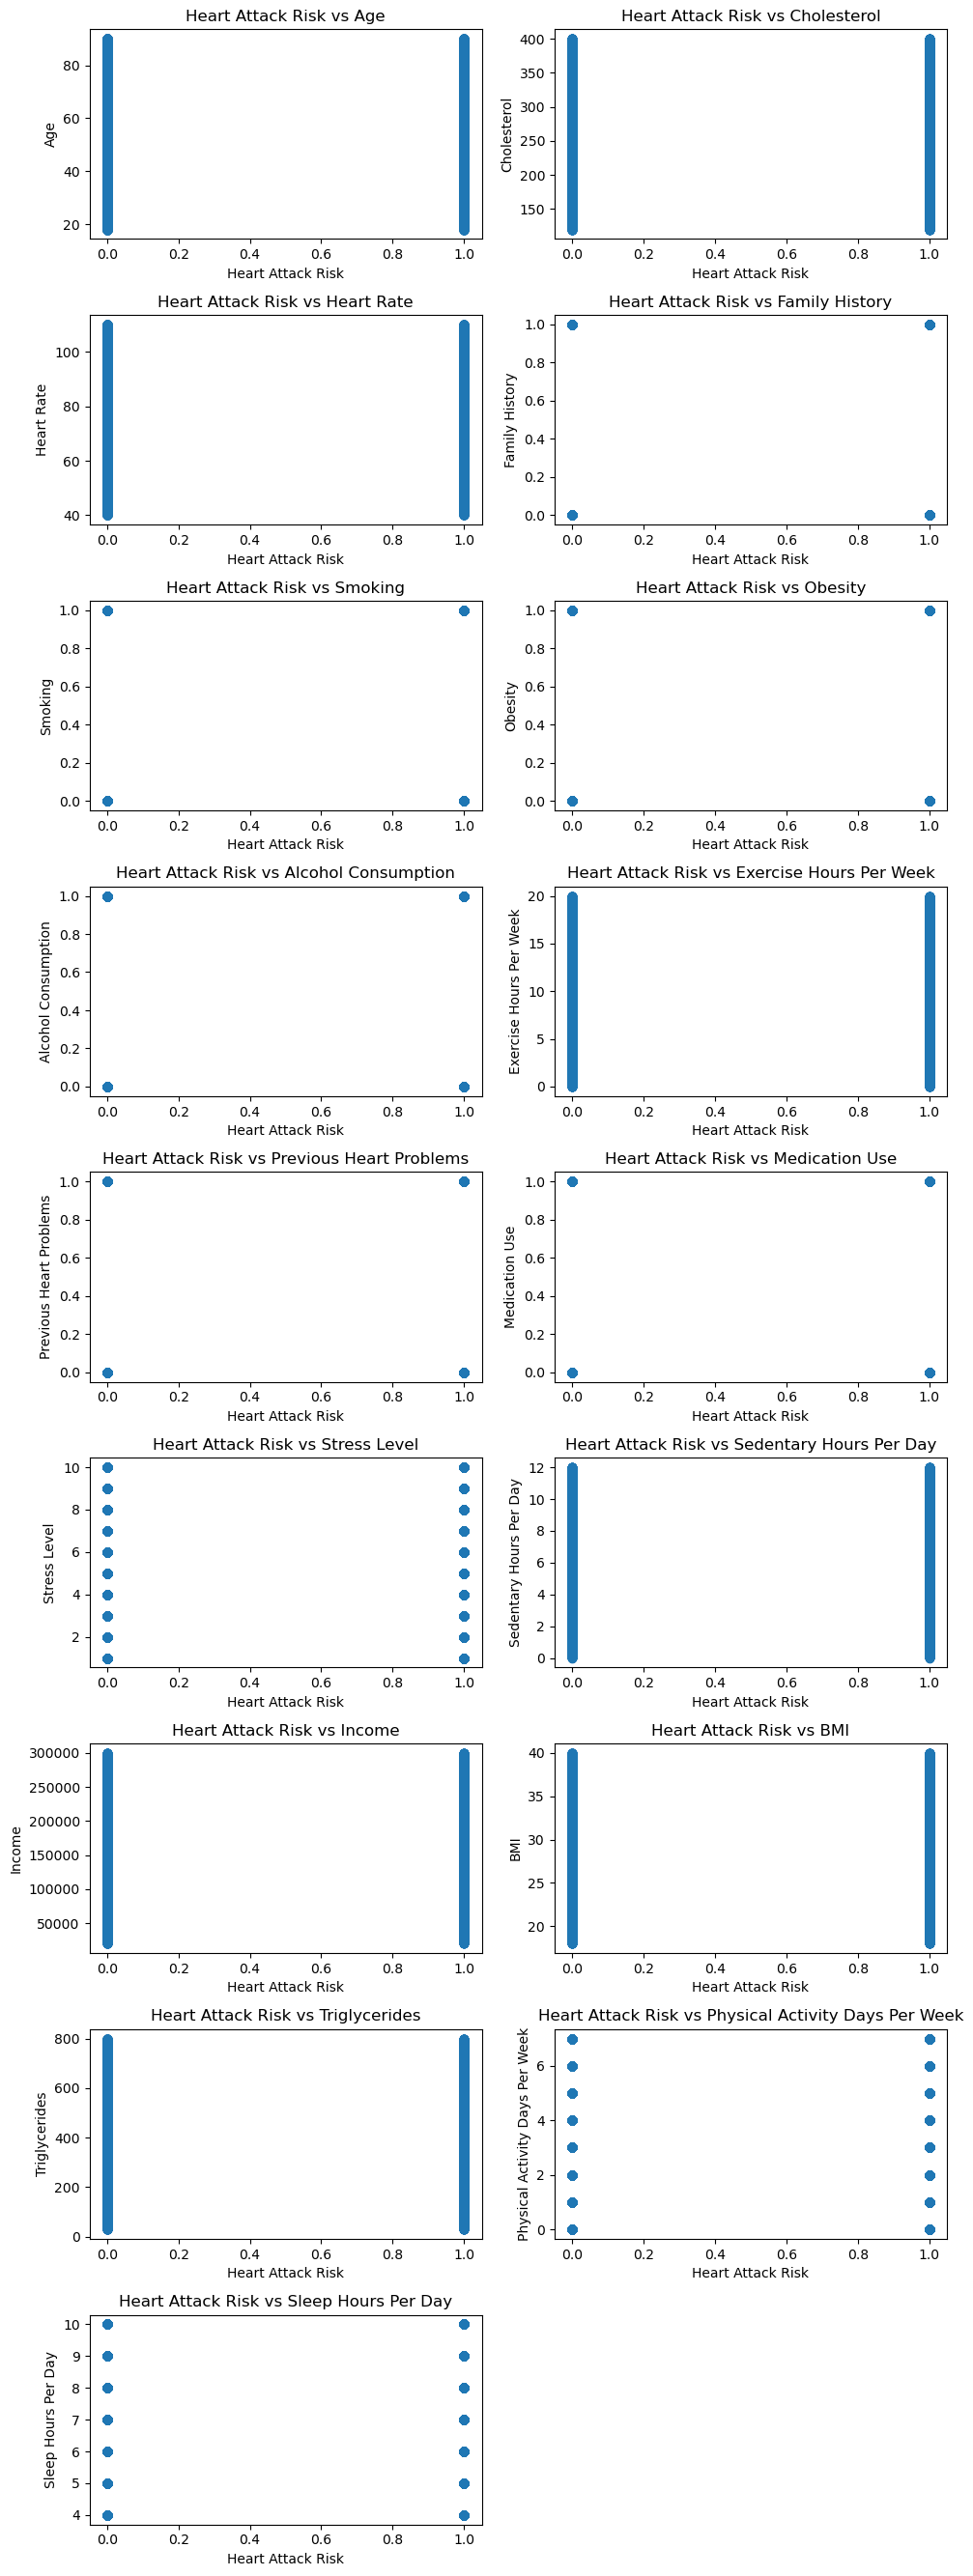

In [18]:
def scatter(y,fig):
    plt.subplot(17,2,fig)
    plt.scatter(data['Heart Attack Risk'],data[y])
    plt.title('Heart Attack Risk vs '+y)
    plt.ylabel(y)
    plt.xlabel('Heart Attack Risk')

plt.figure(figsize=(10,50))

scatter('Age', 1)
scatter('Cholesterol', 2)
scatter('Heart Rate', 3)
scatter('Family History', 4)
scatter('Smoking',5)
scatter('Obesity',6)
scatter('Alcohol Consumption',7)
scatter('Exercise Hours Per Week',8)
scatter('Previous Heart Problems',9)
scatter('Medication Use',10)
scatter('Stress Level',11)
scatter('Sedentary Hours Per Day',12)
scatter('Income',13)
scatter('BMI',14)
scatter('Triglycerides',15)
scatter('Physical Activity Days Per Week',16)
scatter('Sleep Hours Per Day',17)

plt.tight_layout()

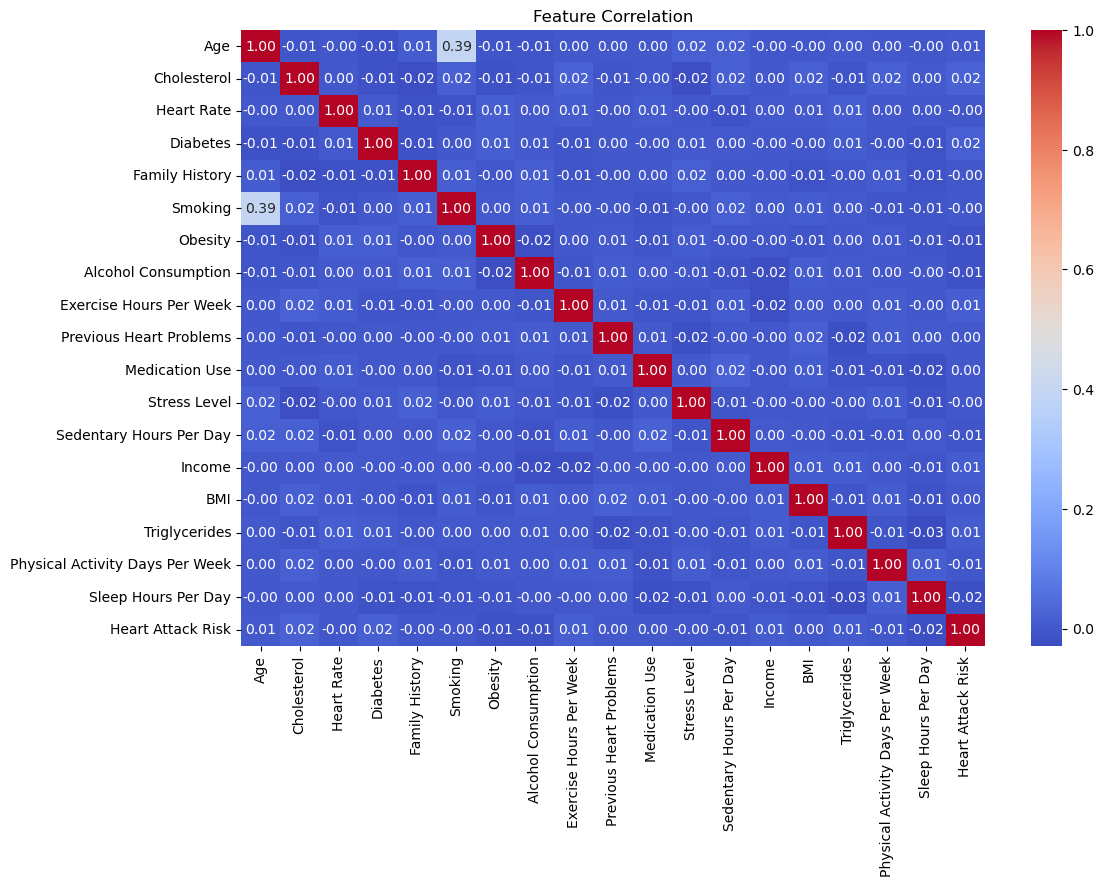

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()


Feature Selection

In [20]:
categorical_features = [x for x in data.columns if data[x].dtype =='object']
categorical_features

['Patient ID',
 'Sex',
 'Blood Pressure',
 'Diet',
 'Country',
 'Continent',
 'Hemisphere']

In [21]:
# drop redundant features
df = data.drop(columns = ['Patient ID', 'Country', 'Continent', 'Hemisphere', 'Income'])
df.head()

,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
0,67,Male,208,158/88,72,0,0,1,0,0,...,Average,0,0,9,6.615001,31.251233,286,0,6,0
1,21,Male,389,165/93,98,1,1,1,1,1,...,Unhealthy,1,0,1,4.963459,27.194973,235,1,7,0
2,21,Female,324,174/99,72,1,0,0,0,0,...,Healthy,1,1,9,9.463426,28.176571,587,4,4,0
3,84,Male,383,163/100,73,1,1,1,0,1,...,Average,1,0,9,7.648981,36.464704,378,3,4,0
4,66,Male,318,91/88,93,1,1,1,1,0,...,Unhealthy,1,0,6,1.514821,21.809144,231,1,5,0


In [22]:
categorical = [x for x in df.columns if df[x].dtype =='object']
categorical

['Sex', 'Blood Pressure', 'Diet']

In [23]:
# divide Blood Pressure feature into two columns
df[['Systolic Pressure', 'Diastolic Pressure']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.head()

,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic Pressure,Diastolic Pressure
0,67,Male,208,158/88,72,0,0,1,0,0,...,0,9,6.615001,31.251233,286,0,6,0,158,88
1,21,Male,389,165/93,98,1,1,1,1,1,...,0,1,4.963459,27.194973,235,1,7,0,165,93
2,21,Female,324,174/99,72,1,0,0,0,0,...,1,9,9.463426,28.176571,587,4,4,0,174,99
3,84,Male,383,163/100,73,1,1,1,0,1,...,0,9,7.648981,36.464704,378,3,4,0,163,100
4,66,Male,318,91/88,93,1,1,1,1,0,...,0,6,1.514821,21.809144,231,1,5,0,91,88


In [24]:
# drop Blood Pressure feature column
df = df.drop(columns=['Blood Pressure'])

In [25]:
categorical_feature = [x for x in df.columns if df[x].dtype =='object']
categorical_feature

['Sex', 'Diet']

In [26]:
# encode Sex feature column
df_encoded = pd.get_dummies(df, columns=['Sex'], drop_first=True)
# encode Diet feature column
df_encoded = pd.get_dummies(df_encoded, columns=['Diet'], drop_first=True)

In [27]:
df_encoded.head()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic Pressure,Diastolic Pressure,Sex_Male,Diet_Healthy,Diet_Unhealthy
0,67,208,72,0,0,1,0,0,4.168189,0,...,31.251233,286,0,6,0,158,88,True,False,False
1,21,389,98,1,1,1,1,1,1.813242,1,...,27.194973,235,1,7,0,165,93,True,False,True
2,21,324,72,1,0,0,0,0,2.078353,1,...,28.176571,587,4,4,0,174,99,False,True,False
3,84,383,73,1,1,1,0,1,9.828130,1,...,36.464704,378,3,4,0,163,100,True,False,False
4,66,318,93,1,1,1,1,0,5.804299,1,...,21.809144,231,1,5,0,91,88,True,False,True


In [28]:
df2 = df_encoded.copy()

cols_to_convert = ["Sex_Male", "Diet_Healthy", "Diet_Unhealthy"]
df2[cols_to_convert] = df2[cols_to_convert].astype("int64")

data_new = df2.copy()

In [29]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8763 non-null   int64  
 1   Cholesterol                      8763 non-null   int64  
 2   Heart Rate                       8763 non-null   int64  
 3   Diabetes                         8763 non-null   int64  
 4   Family History                   8763 non-null   int64  
 5   Smoking                          8763 non-null   int64  
 6   Obesity                          8763 non-null   int64  
 7   Alcohol Consumption              8763 non-null   int64  
 8   Exercise Hours Per Week          8763 non-null   float64
 9   Previous Heart Problems          8763 non-null   int64  
 10  Medication Use                   8763 non-null   int64  
 11  Stress Level                     8763 non-null   int64  
 12  Sedentary Hours Per 

In [30]:
# save cleaned data
data_new.to_csv("/workspaces/Heart-Attack-Predictor/notebooks/FC212041_Isivara/cleaned_heart_attack_risk_dataset.csv", index=False)